Prognozowanie wilgotności gleby dla systemów nawadniania

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

In [29]:
# wilgotnosc gleby - symulacja
np.random.seed(42)
time = np.linspace(0, 100, 800)

trend = 0.01 * time
seasonal = np.sin(time / 3) + 0.5 * np.sin(time / 7)
noise = np.random.normal(0, 0.3, len(time))

soil_moisture = trend + seasonal + noise
soil_moisture = soil_moisture.reshape(-1, 1)

In [30]:
# normalizacja danych
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(soil_moisture)

In [31]:
# funkcja do tworzenia sekwencji
def create_dataset(data, look_back=20):
    X, y = [], []
    for i in range(len(data)-look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [32]:
model = Sequential([
    Input(shape=(X.shape[1], 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0693 - val_loss: 0.0210
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0105 - val_loss: 0.0086
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0076 - val_loss: 0.0082
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0065 - val_loss: 0.0090
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0061 - val_loss: 0.0066
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0059 - val_loss: 0.0061
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0059 - val_loss: 0.0069
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0054 - val_loss: 0.0059
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0053 - val_loss: 0.0057
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0051 - val_loss: 0.0064
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


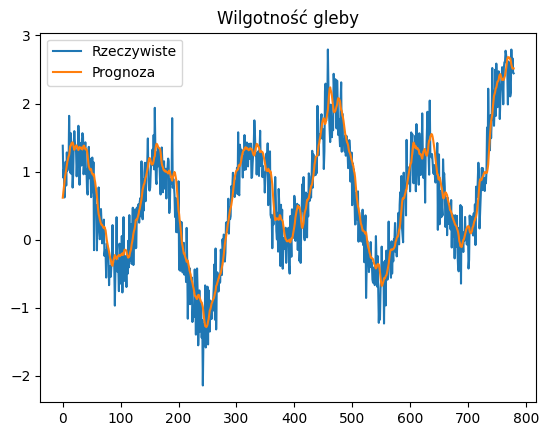

In [33]:
# predykcja, wykres
pred = model.predict(X)
pred = scaler.inverse_transform(pred)
real = scaler.inverse_transform(y)

plt.plot(real, label="Rzeczywiste")
plt.plot(pred, label="Prognoza")
plt.legend()
plt.title("Wilgotność gleby")
plt.show()

Wykrywanie anomalii w danych z dronów rolniczych

In [18]:
from sklearn.model_selection import train_test_split

In [47]:
# symulacja danych z drona
def generate_drone_data(n=1500, t=15):
    X = []
    y = []

    for _ in range(n):
        base = np.sin(np.linspace(0, 3*np.pi, t))
        noise = np.random.normal(0, 0.3, t)
        sequence = base + noise

        # dodanie anomalii - losowo
        if np.random.rand() < 0.2:
            idx = np.random.randint(3, t-3)
            sequence[idx:idx+2] += np.random.normal(1.5, 0.3, 2)
            label = 1
        else:
            label = 0

        X.append(sequence)
        y.append(label)

    return np.array(X), np.array(y)

X, y = generate_drone_data()
X = X.reshape((X.shape[0], X.shape[1], 1))

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [49]:
model = Sequential([
    Input(shape=(X.shape[1], 1)),
    LSTM(32, return_sequences=True),
    LSTM(16),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8175 - loss: 0.5802 - val_accuracy: 0.8033 - val_loss: 0.4946
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8250 - loss: 0.4007 - val_accuracy: 0.8300 - val_loss: 0.3055
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9017 - loss: 0.2444 - val_accuracy: 0.9367 - val_loss: 0.1945
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9425 - loss: 0.1765 - val_accuracy: 0.9433 - val_loss: 0.1568
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9483 - loss: 0.1491 - val_accuracy: 0.9433 - val_loss: 0.1435
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9667 - loss: 0.1104 - val_accuracy: 0.9633 - val_loss: 0.0978
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9767 - loss: 0.0889 - val_accuracy: 0.9600 - val_loss: 0.1079
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9800 - loss: 0.0774 - val_accuracy: 0.9700 - v

In [37]:
loss, acc = model.evaluate(X_test, y_test)
print("Dokładność:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9800 - loss: 0.0508 
Dokładność: 0.9800000190734863


Rozpoznawanie faz wzrostu roślin na podstawie danych czujnikowych

In [23]:
import tensorflow as tf

In [38]:
# funkcja faz wzrostu - niech: 0 - kiełkowanie, 1 - wzrost, 2 - kwitnienie
def generate_plant_data(n=1800, t=25):
    X, y = [], []

    for label in range(3):
        for _ in range(n//3):
            base = np.linspace(0, 1, t)

            if label == 0:  # kiełkowanie
                seq = base * 0.5 + np.random.normal(0, 0.2, t)
            elif label == 1:  # wzrost
                seq = base + 0.3*np.sin(np.linspace(0, 3*np.pi, t)) + np.random.normal(0, 0.2, t)
            else:  # kwitnienie
                seq = base + 0.6*np.sin(np.linspace(0, 5*np.pi, t)) + np.random.normal(0, 0.3, t)

            X.append(seq)
            y.append(label)

    return np.array(X), np.array(y)

X, y = generate_plant_data()
X = X.reshape((X.shape[0], X.shape[1], 1))
y = tf.keras.utils.to_categorical(y, 3)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [45]:
model = Sequential([
    Input(shape=(X.shape[1], 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=6, validation_data=(X_test, y_test))

Epoch 1/6
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4868 - loss: 0.8702 - val_accuracy: 0.6694 - val_loss: 0.6130
Epoch 2/6
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6917 - loss: 0.5355 - val_accuracy: 0.7222 - val_loss: 0.4791
Epoch 3/6
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7264 - loss: 0.4676 - val_accuracy: 0.7639 - val_loss: 0.4405
Epoch 4/6
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8278 - loss: 0.3714 - val_accuracy: 0.9500 - val_loss: 0.2398
Epoch 5/6
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9618 - loss: 0.1327 - val_accuracy: 0.9833 - val_loss: 0.0626
Epoch 6/6
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9931 - loss: 0.0296 - val_accuracy: 0.9917 - val_loss: 0.0333


In [46]:
loss, acc = model.evaluate(X_test, y_test)
print("Dokładność:", acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9917 - loss: 0.0333
Dokładność: 0.9916666746139526
